Traveling salesman
==================

**Author:** Rafael



## Instancia



Una instancia del problema del agente viajero es una gráfica completa con $n$ vértices con pesos en cada una de las aristas. El problema consiste en hallar una permutación de los vértices $x_{0},x_{1},\ldots,x_{n}$ que minimice la suma de los pesos de las aristas $x_{0}x_{1},x_{1}x_{2},\ldots,x_{n-1}x_{n},x_{n}x_{0}$.

Podemos definir una instancia aleatoria del problema con una gráfica de `networkx`, añadiendo los pesos a las aristas como números aleatorios.



In [1]:
import networkx as nx
import random

G = nx.complete_graph(10)
for (u, v) in G.edges():
    G.edges[u,v]['weight'] = random.randint(1, 100)
G

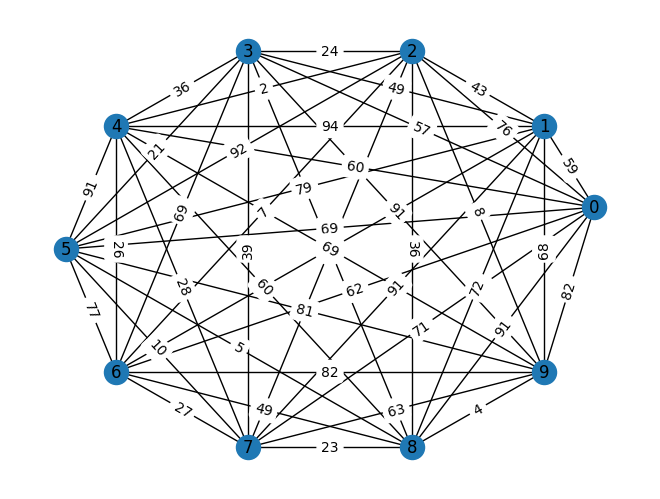

In [1]:
import matplotlib.pyplot as plt
from numpy import array
pos = nx.circular_layout(G)
pos[0] = array([1, 0.2])
nx.draw(G, pos, with_labels=True)
nx.draw_networkx_edge_labels(G, pos, edge_labels=nx.get_edge_attributes(G, 'weight'))
plt.show()

In [1]:
pos

{0: array([1. , 0.2]),
 1: array([0.809017  , 0.58778526]),
 2: array([0.30901698, 0.95105655]),
 3: array([-0.30901702,  0.95105649]),
 4: array([-0.80901699,  0.58778526]),
 5: array([-9.99999988e-01, -7.27200340e-08]),
 6: array([-0.80901693, -0.58778529]),
 7: array([-0.30901711, -0.95105646]),
 8: array([ 0.30901713, -0.95105646]),
 9: array([ 0.80901694, -0.58778529])}

Pero para mayor conveniencia, definimos una clase que nos dé una instancia aleatoria del problema teniendo como único parámetro la cantidad de ciudades. De esa manera podemos definir algunos métodos convenientes.



In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import random
from dataclasses import dataclass, field

@dataclass
class TSPInstance:
    num_cities: int
    # graph: nx.Graph = field(init=False)

    def __post_init__(self):
        # Creates a complete graph with nodes 0 to n-1
        self.graph = nx.complete_graph(self.num_cities)
        for (u, v) in self.graph.edges():
            self.graph.edges[u, v]['weight'] = random.randint(10, 100)

    def draw(self):
        """Draws the graph with edge weights displayed."""
        pos = nx.circular_layout(self.graph)
        nx.draw(self.graph, pos, with_labels=True, node_color='cyan', 
                node_size=500, font_weight='bold')
        edge_labels = nx.get_edge_attributes(self.graph, 'weight')
        nx.draw_networkx_edge_labels(self.graph, pos, edge_labels=edge_labels)
        plt.show()

    def get_cost(self, u, v):
        return self.graph[u][v]['weight']

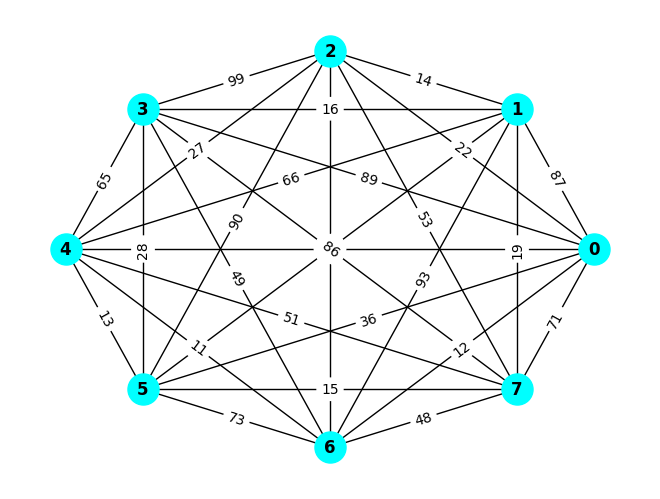

In [1]:
G = TSPInstance(8)
G.draw()

In [1]:
G.get_cost(0, 4)

69

De esta manera, definimos un primer enfoque a la solución del problema utilizando *backtracking*. Notemos que, sin perder generalidad, podemos suponer que la permutación de los vértices comienza siempre en el vértice 0.



In [1]:
def solve_tsp_exhaustive(instance: TSPInstance):
    best = {"cost": float('inf'), "selection": []}
    
    n = instance.num_cities

    def solve(idx, X):
        # If idx == n, we have visited all cities
        if idx == n:
            # Calculate total cost of the path [X0, ..., Xn-1]
            c = 0
            for i in range(n - 1):
                c += instance.get_cost(X[i], X[i+1])
                # Add the return to the start city to complete the cycle
            c += instance.get_cost(X[n-1], X[0])
            
            if c < best["cost"]:
                best["cost"] = c
                best["selection"] = X[:]

        choices = [i for i in range(1, n) if i not in X]

        for city in choices:
            X.append(city)
            solve(idx + 1, X)
            X.pop()  # Backtrack

    # Run the recursive solver starting at level 0
    solve(1, [0])
    return best

In [1]:
prob = TSPInstance(8)

In [1]:
solve_tsp_exhaustive(prob)

{'cost': 237, 'selection': [0, 2, 6, 7, 4, 3, 1, 5]}

## Función acotadora



In [1]:
def _b_min_edge(instance, u, city_set):
    """Calculates b(u, V): minimum cost from city u to any city in city_set."""
    return min(instance.get_cost(u, v) for v in city_set)

def bounding_tsp(instance, X):
    """
    Calculates the optimistic bound B based on the current path X.
    """
    idx = len(X)
    n = instance.num_cities
    
    # current_path_cost: sum of edges in the partial path
    path_cost = sum(instance.get_cost(X[i], X[i+1]) for i in range(idx - 1))
    
    if idx < n:
        unvisited = set(range(n)) - set(X)
        # Bound = Path + leave_last_city + sum(leave_unvisited_cities)
        term_to_unvisited = _b_min_edge(instance, X[idx-1], unvisited)
        
        term_from_unvisited = 0
        start_city = X[0]
        for y in unvisited:
            # Destinations for y: other unvisited cities OR return to start
            destinations = (unvisited - {y}) | {start_city}
            term_from_unvisited += _b_min_edge(instance, y, destinations)
            
        return path_cost + term_to_unvisited + term_from_unvisited
    else:
        # Full tour completion
        return path_cost + instance.get_cost(X[n-1], X[0])

def solve_tsp_bound(instance: TSPInstance):
    best = {"cost": float('inf'), "selection": []}
    n = instance.num_cities

    def solve(idx, X):
        if idx == n:
            final_cost = bounding_tsp(instance, X)
            if final_cost < best["cost"]:
                best["cost"] = final_cost
                best["selection"] = X[:]
        else:
            choices = [i for i in range(n) if i not in X]

            for city in choices:
                B = bounding_tsp(instance, X)
                if B < best["cost"]:
                    X.append(city)
                    solve(idx + 1, X)
                    X.pop()

    solve(1, [0])
    return best

In [1]:
solve_tsp_bound(prob)

{'cost': 237, 'selection': [0, 2, 6, 7, 4, 3, 1, 5]}

## Branch and bound



Ahora recorremos las opciones en orden de acuerdo al valor de la función acotadora (las opciones parciales tales que la función acotadora es menor tienen mayor probabilidad de llegar a generar un mínimo, o al menos, podar mayor cantidad de ramas).



In [1]:
def solve_tsp_ordered(instance: TSPInstance):
    best = {"cost": float('inf'), "selection": []}
    n = instance.num_cities

    def solve(idx, X):
        if idx == n:
            final_cost = bounding_tsp(instance, X)
            if final_cost < best["cost"]:
                best["cost"] = final_cost
                best["selection"] = X[:]
        else:
            potential_cities = [i for i in range(n) if i not in X]

            # 1. Evaluate bounds for all potential candidates
            candidates = []
            for city in potential_cities:
                X.append(city)
                B = bounding_tsp(instance, X)
                # Only keep candidates that could potentially beat current best
                if B < best["cost"]:
                    candidates.append((B, city))
                X.pop()

            # 2. Sort choices: Smallest bound first (Best-First Search behavior)
            candidates.sort(key=lambda x: x[0])
            choices = [city for bound, city in candidates]

            # 3. Explore ordered choices
            for city in choices:
                X.append(city)
                if bounding_tsp(instance, X) < best["cost"]:
                    solve(idx + 1, X)
                X.pop()

    solve(1, [0])
    return best

In [1]:
solve_tsp_ordered(prob)

{'cost': 237, 'selection': [0, 2, 6, 7, 4, 3, 1, 5]}

## Comparación de resultados



In [1]:
prob = TSPInstance(9)

In [1]:
solve_tsp_exhaustive(prob)

{'cost': 312, 'selection': [0, 2, 6, 4, 5, 8, 3, 1, 7]}

In [1]:
solve_tsp_bound(prob)

{'cost': 312, 'selection': [0, 2, 6, 4, 5, 8, 3, 1, 7]}

In [1]:
solve_tsp_ordered(prob)

{'cost': 312, 'selection': [0, 2, 6, 4, 5, 8, 3, 1, 7]}